c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\dgl\dataloading\dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


{
  "accuracy": 0.011480201966516078,
  "macro": {
    "precision": 0.2802163511545662,
    "recall": 0.19025471095496646,
    "f1": 0.06100435787195461
  },
  "macro_FAR": 0.24712785519257013,
  "macro_precision": 0.2802163511545662,
  "macro_recall": 0.19025471095496646
}
False negatives by class: {'Benign': 3, 'DDoS': 18579, 'DoS': 0, 'Reconnaissance': 0}


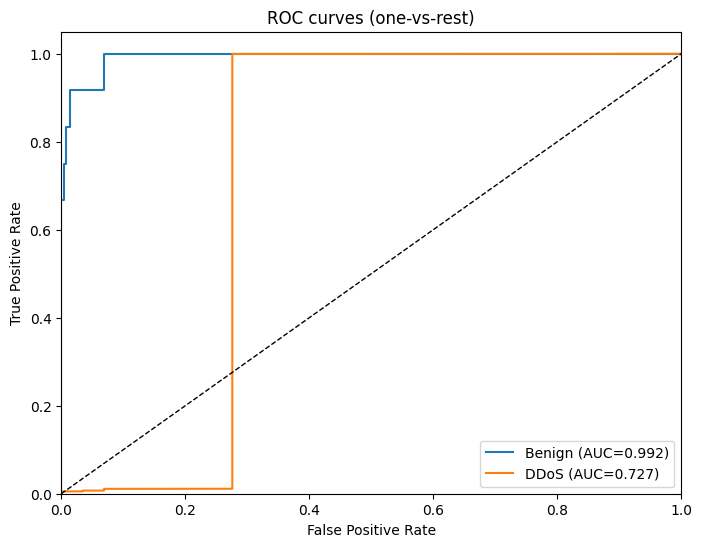

In [1]:
import os
os.chdir(r'C:\Users\nq100\Downloads\TE-G-SAGE-XAI-workspace\TE-G-SAGE-XAI\netflow')
import os, json, joblib, dgl, torch
import numpy as np
from feature_store import fetch_edge_features
from eval_utils import make_eval_loader
from eval_infer import infer_split
from eval_metrics import compute_metrics
from eval_roc import plot_roc_ovr, false_negatives_by_class

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load artifacts
g_val = dgl.load_graphs("graphs/test.bin")[0][0]
fs_val = "feature_store/test"

# label map
with open("artifacts/label_map.json","r",encoding="utf-8") as f:
    label2id = json.load(f)
id2label = {v:k for k,v in label2id.items()}
classes  = [id2label[i] for i in range(len(label2id))]

# 1) read best params if available (fall back to sensible defaults)
best_params_path = "artifacts/best_params.json"
if os.path.exists(best_params_path):
    with open(best_params_path, "r", encoding="utf-8") as f:
        best = json.load(f)
    cfg = best.get("config", {})
    model_path = best.get("model_path", "artifacts/best_edge_sage.pt")
else:
    cfg = {}
    model_path = "artifacts/best_edge_sage.pt"

# 2) derive required hyperparams (use defaults if missing)
hidden = int(cfg.get("hidden", 128))
dropout = float(cfg.get("dropout", 0.3))
fanouts_dict = cfg.get("fanouts", "25,15")
fanouts = tuple(map(int, fanouts_dict.split(",")))
batch_size = int(cfg.get("batch_size", 2048))

# Rebuild the model (must match your training config)
edge_in = fetch_edge_features(np.load(os.path.join(fs_val,"edge_indices.npy"))[:1], fs_val).shape[1]
num_classes = len(label2id)

from models.edge_graphsage import EdgeGraphSAGE as _FallbackEdgeGraphSAGE
model = _FallbackEdgeGraphSAGE(in_node=0, edge_in=edge_in, hidden=hidden, num_classes=num_classes, dropout=dropout).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Build loader for VAL
val_loader = make_eval_loader(g_val, fs_val, fanouts=fanouts, batch_size=batch_size)

# Inference
y_true, y_pred, y_prob = infer_split(model, val_loader, g_val, device, fetch_edge_features)

# Metrics
metrics = compute_metrics(y_true, y_pred, label2id)
# pull macro precision/recall (safe-get in case compute_metrics shape differs)
macro = metrics.get("macro", {})
macro_precision = macro.get("precision", None)
macro_recall = macro.get("recall", None)

print(json.dumps({
    "accuracy": metrics["accuracy"],
    "macro": metrics["macro"],
    "macro_FAR": metrics["macro_FAR"],
    "macro_precision": macro_precision,
    "macro_recall": macro_recall
}, indent=2))
# Confusion Matrix & FN
cm = np.array(metrics["confusion_matrix"])
fn_by_class = false_negatives_by_class(cm, classes)
print("False negatives by class:", fn_by_class)

# Save metrics
os.makedirs("artifacts", exist_ok=True)
with open("artifacts/metrics_test.json","w") as f:
    json.dump(metrics, f, indent=2)

# ROC curves
plot_roc_ovr(y_true, y_prob, classes, out_path="artifacts/roc_test.png")


# Calculate and plot metrics
Calculate binary metric and Per-class metrics.

Binary metrics (pos = not Benign):
  TP=18743, FP=3, TN=9, FN=60
  Precision = 0.9998
  Recall = 0.9968
  F1 = 0.9983
  TNR (specificity) = 0.7500
  FAR (FPR) = 0.2500


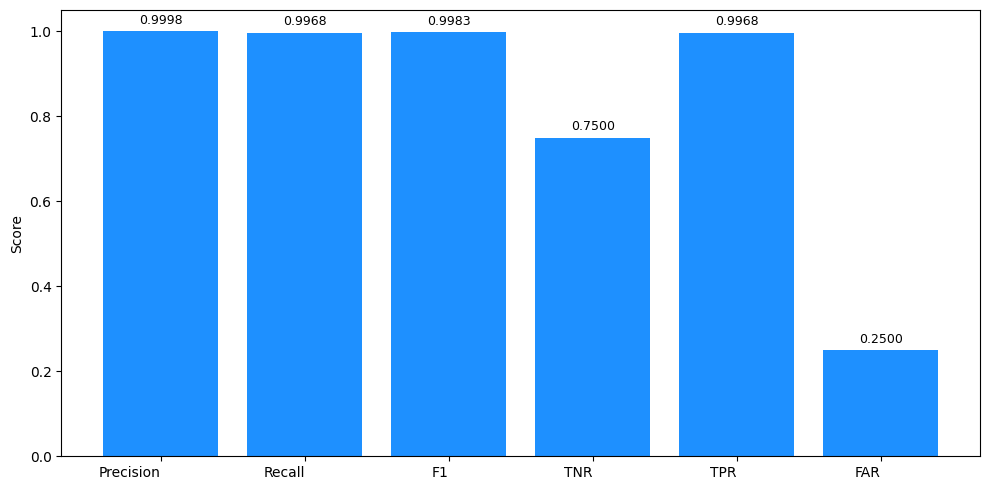

<Figure size 600x500 with 0 Axes>

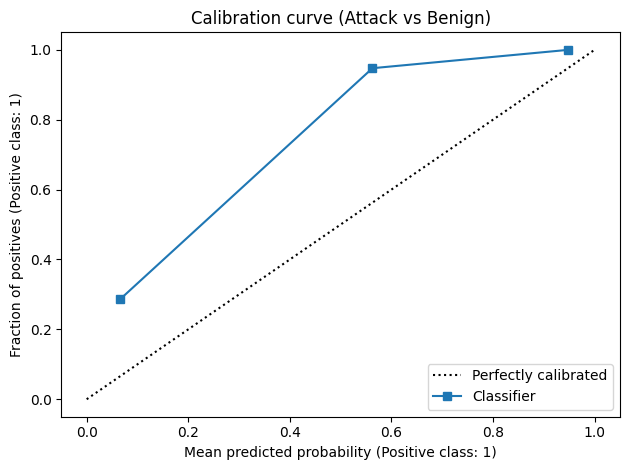

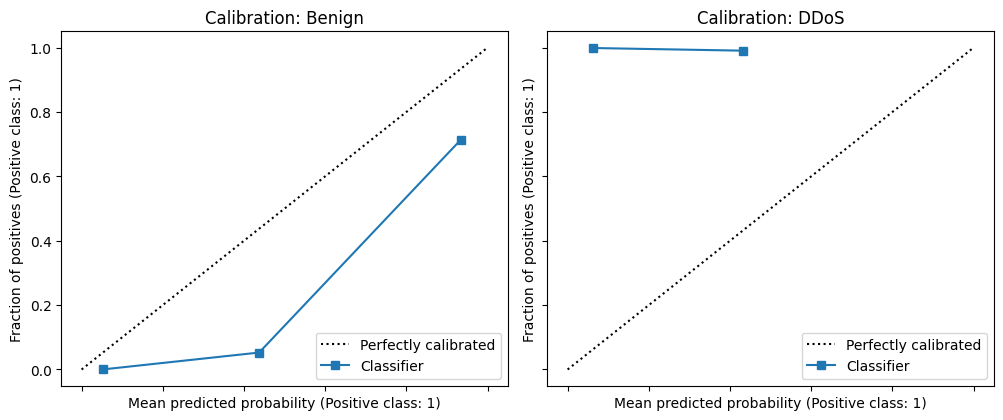

In [2]:
# binary classification metrics for "Attack" vs "Benign"
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# labels: list[str] in ID order, e.g. ["Benign", "DoS", "DDoS", ...]
# y_true, y_pred: integer class IDs (0..K-1)
labels = [id2label[i] for i in range(len(id2label))]
# choose which class ID is negative (Benign)
neg_name = "Benign"
neg_id = labels.index(neg_name)

# build binary targets: positive = any class != Benign
y_true_bin = (y_true != neg_id).astype(int)
y_pred_bin = (y_pred != neg_id).astype(int)

# confusion matrix for binary case: rows=true, cols=pred, order [0, 1] = [neg, pos]
cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
TN, FP, FN, TP = cm_bin.ravel()

# metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall   = TP / (TP + FN) if (TP + FN) > 0 else 0.0      # TPR
f1       = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
tnr      = TN / (TN + FP) if (TN + FP) > 0 else 0.0      # specificity
tpr      = recall                                        # alias
far      = FP / (FP + TN) if (FP + TN) > 0 else 0.0      # = 1 - TNR

print(f"Binary metrics (pos = not {neg_name}):")
print(f"  TP={TP}, FP={FP}, TN={TN}, FN={FN}")
print(f"  Precision = {precision:.4f}")
print(f"  Recall = {tpr:.4f}")
print(f"  F1 = {f1:.4f}")
print(f"  TNR (specificity) = {tnr:.4f}")
print(f"  FAR (FPR) = {far:.4f}")

metric_names = ["Precision", "Recall", "F1", "TNR", "TPR", "FAR"]
metric_values = [precision, recall, f1, tnr, tpr, far]

x = np.arange(len(metric_names))

plt.figure(figsize=(10, 5))
bars = plt.bar(x, metric_values, color="dodgerblue")

plt.xticks(x, metric_names, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.tight_layout()

# annotate each bar with its value
for bar, val in zip(bars, metric_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/Metrics_binary.png", dpi=200)
plt.show()

#Binary calibration curve
from sklearn.calibration import CalibrationDisplay

# probability of "Attack" = 1 - P(Benign)
prob_benign = y_prob[:, neg_id]
prob_attack = 1.0 - prob_benign

plt.figure(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_true_bin,           # 0 = Benign, 1 = Attack
    prob_attack,          # predicted prob of Attack
    n_bins=3,
    strategy="uniform"    # or "quantile"
)
plt.title("Calibration curve (Attack vs Benign)")
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/calibration_attack_vs_benign.png", dpi=200)
plt.show()

# Multi-class calibration 

from sklearn.calibration import CalibrationDisplay

num_classes = y_prob.shape[1]

fig, axes = plt.subplots(
    nrows=int(np.ceil(num_classes / 3)),
    ncols=3,
    figsize=(15, 4 * int(np.ceil(num_classes / 3))),
    sharex=True,
    sharey=True,
)
axes = axes.ravel()

for c in range(num_classes):
    ax = axes[c]
    # binary targets: 1 if true class == c else 0
    y_true_c = (y_true == c).astype(int)
    y_prob_c = y_prob[:, c]  # P(class c)

    # skip classes with no positives
    if y_true_c.sum() == 0:
        ax.set_visible(False)
        continue

    CalibrationDisplay.from_predictions(
        y_true_c,
        y_prob_c,
        n_bins=3,
        strategy="uniform",
        ax=ax,
    )
    ax.set_title(f"Calibration: {classes[c]}")

# hide unused axes
for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
os.makedirs("artifacts", exist_ok=True)
fig.savefig("artifacts/calibration_per_class_sklearn.png", dpi=200, bbox_inches="tight")
plt.show()

class=Benign               FPR=0.0031
class=DDoS                 FPR=0.0000
class=DoS                  FPR=0.9849
class=Reconnaissance       FPR=0.0004


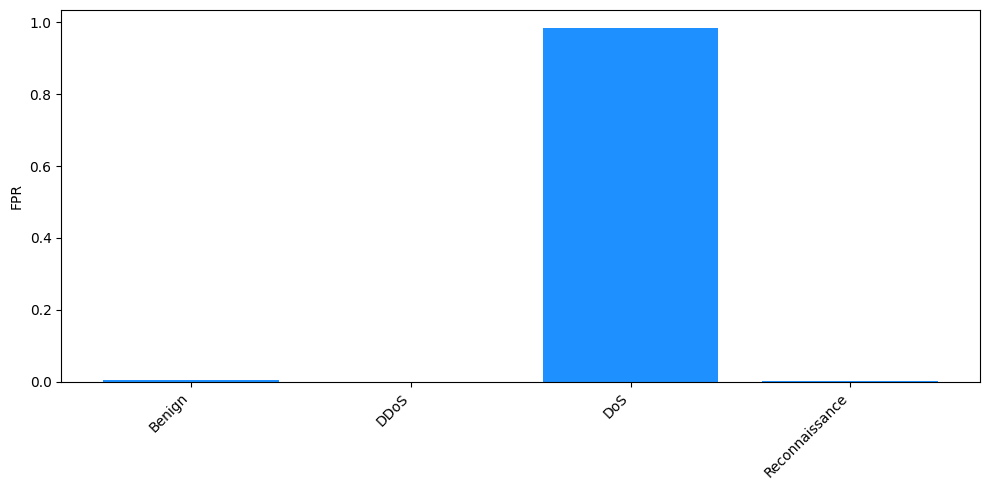

In [3]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Calculate FPR per class
# FPR_c = FP_c / (FP_c + TN_c)
#cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
K = cm.shape[0]
labels = [id2label[i] for i in range(len(id2label))]

fpr = np.zeros(K, dtype=float)
for c in range(K):
    TP = cm[c, c]
    FN = cm[c, :].sum() - TP          # row c, except TP
    FP = cm[:, c].sum() - TP          # column c, except TP
    TN = cm.sum() - (TP + FN + FP)
    fpr[c] = FP / (FP + TN) if (FP + TN) > 0 else 0.0

for name, v in zip(labels, fpr):
    print(f"class={name:20s} FPR={v:.4f}")

#   labels = [...]           # class names, incl. "Benign"
#   fpr    = fpr             # array with per-class FPR

# Plot FPR - False Positive Rate
plt.figure(figsize=(10, 5))
x = np.arange(len(labels))
plt.bar(x, fpr, color="dodgerblue")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("FPR")
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/Metrics_fpr_per_class.png", dpi=200)
plt.show()

Plot standard curves

c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\nq100\miniconda3\DLLs\envs\te-g-sage\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


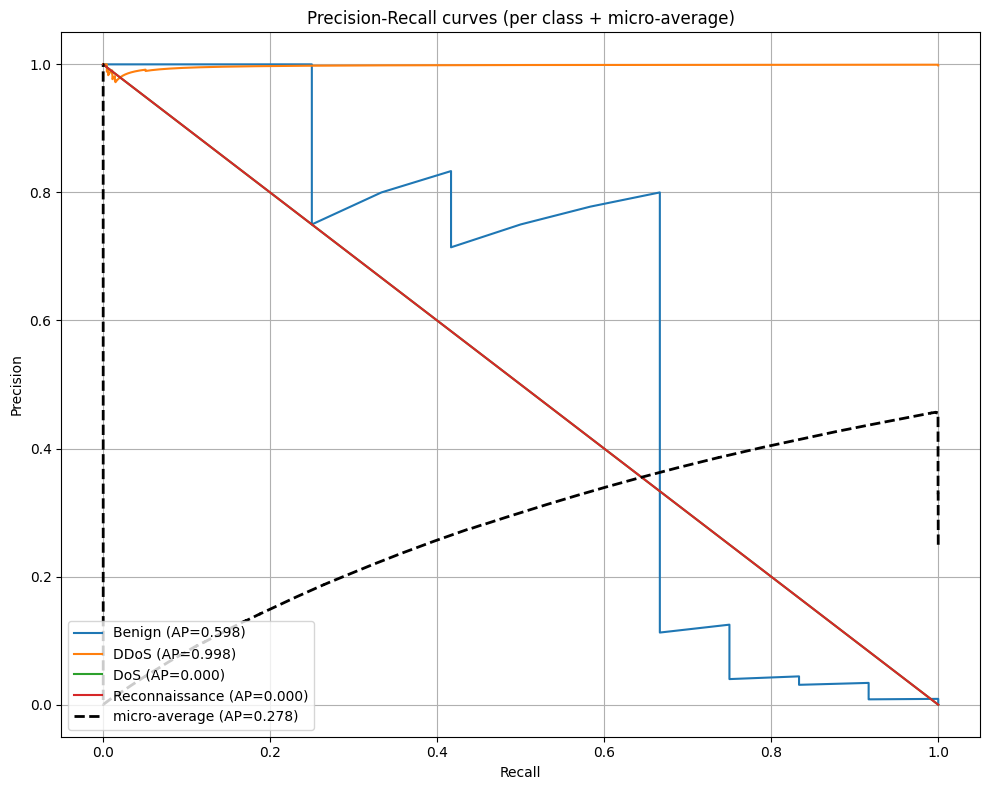

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import matplotlib as mpl

# Ensure y_prob is a NumPy array (infer_split returned logits)
if isinstance(y_prob, torch.Tensor):
    y_prob = y_prob.detach().cpu().numpy()

# Convert logits -> probabilities (binary or multiclass)
if y_prob.ndim == 1 or (y_prob.ndim == 2 and y_prob.shape[1] == 1):
    logits = y_prob.reshape(-1)
    probs_pos = 1.0 / (1.0 + np.exp(-logits))
    y_prob = np.vstack([1.0 - probs_pos, probs_pos]).T
else:
    logits = y_prob
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits)
    y_prob = exp / exp.sum(axis=1, keepdims=True)

# y_true (N,), y_prob (N, C) ready for PR plotting
num_classes = y_prob.shape[1]

# binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# compute per-class PR and AP
plt.figure(figsize=(10, 8))
colors = mpl.colormaps['tab10']
for i in range(num_classes):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    plt.plot(rec, prec, label=f"{classes[i]} (AP={ap:0.3f})", color=colors(i % 10))

# micro-average
prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
ap_micro = average_precision_score(y_true_bin, y_prob, average="micro")
plt.plot(rec_micro, prec_micro, label=f"micro-average (AP={ap_micro:0.3f})", color='black', linewidth=2, linestyle='--')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (per class + micro-average)")
plt.legend(loc="lower left", fontsize="medium")
plt.grid(True)
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/pr_curve_test.png", dpi=200)
plt.show()

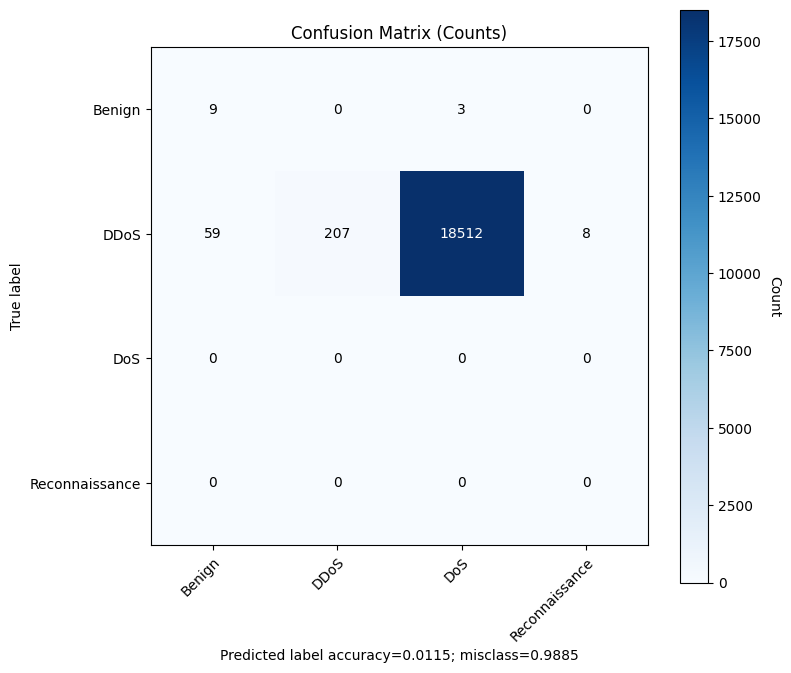

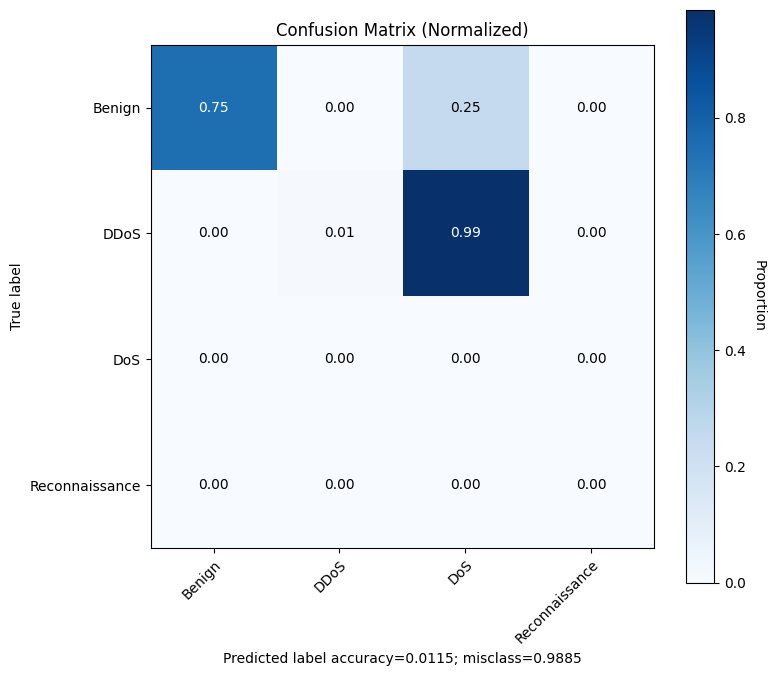

In [5]:
from eval_roc import plot_confusion_matrix

# labels must be list[str] in index order: [id0_name, id1_name, ...]
labels = [label2id_key for label2id_key in label2id.keys()]  # or build from id→label map
# Raw counts:
cm_counts = plot_confusion_matrix(y_true, y_pred, labels, normalize=False, title="Confusion Matrix (Counts)",
                                  savepath="artifacts/confusion_matrix_counts.png")
# Normalized (by true class / row):
cm_norm = plot_confusion_matrix(y_true, y_pred, labels, normalize=True, title="Confusion Matrix (Normalized)",
                                savepath="artifacts/confusion_matrix_normalized.png")


In [6]:
from sklearn.metrics import confusion_matrix

def per_class_errors(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    fn = cm.sum(axis=1) - np.diag(cm)  # false negatives per true class (missed)
    fp = cm.sum(axis=0) - np.diag(cm)  # false positives per predicted class
    return cm, fn, fp

cm, fn, fp = per_class_errors(y_true, y_pred, labels)
print("False negatives per class:")
for name, v in zip(labels, fn):
    print(f"  {name}: {int(v)}")


False negatives per class:
  Benign: 3
  DDoS: 18579
  DoS: 0
  Reconnaissance: 0


C:\Users\nq100\AppData\Local\Temp\ipykernel_27664\1543313044.py:5: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


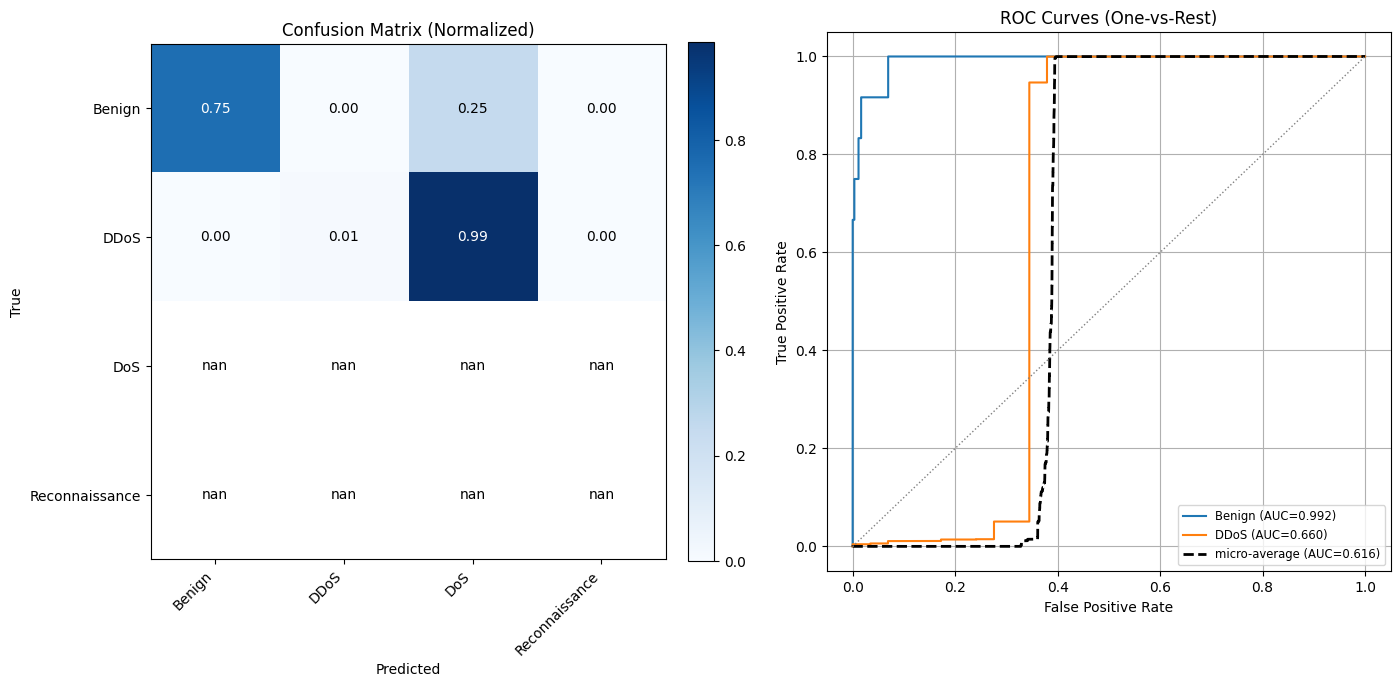

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Confusion Matrix (Normalized)
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = axes[0].imshow(cm_norm, cmap="Blues")
axes[0].set_title("Confusion Matrix (Normalized)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_xticks(np.arange(len(labels))); axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_yticks(np.arange(len(labels))); axes[0].set_yticklabels(labels)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[0].text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                     color="white" if cm_norm[i,j] > 0.5 else "black")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

from sklearn.metrics import roc_curve, auc

n_classes = y_prob.shape[1]
y_true_bin_local = y_true_bin  # already computed in the notebook
axr = axes[1]
import matplotlib as mpl
cmap = mpl.colormaps['tab10']

fpr = {}
tpr = {}
roc_auc = {}

# per-class ROC
for i in range(n_classes):
    if np.sum(y_true_bin_local[:, i]) == 0:
        # no positive samples for this class in y_true -> skip plotting
        continue
    fpr[i], tpr[i], _ = roc_curve(y_true_bin_local[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    axr.plot(fpr[i], tpr[i], color=cmap(i % 10), lw=1.5, label=f"{classes[i]} (AUC={roc_auc[i]:0.3f})")

# micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin_local.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
axr.plot(fpr["micro"], tpr["micro"], color="black", lw=2, linestyle="--", label=f"micro-average (AUC={roc_auc['micro']:0.3f})")

# chance line and formatting
axr.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
axr.set_title("ROC Curves (One-vs-Rest)")
axr.set_xlabel("False Positive Rate")
axr.set_ylabel("True Positive Rate")
axr.legend(loc="lower right", fontsize="small")
axr.grid(True)

# save combined figure
os.makedirs("artifacts", exist_ok=True)
fig.savefig("artifacts/roc_vs_confusion.png", dpi=200, bbox_inches="tight")


# Prepare table of results

In [8]:
import json, dgl, numpy as np, pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

# id2label in ID order
with open("artifacts/label_map.json","r") as f:
    label2id = json.load(f)
id2label = {v:k for k,v in label2id.items()}
labels = [id2label[i] for i in range(len(id2label))]

# Per-class precision/recall/F1
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(labels))), zero_division=0
)

# FAR per class (one-vs-rest)
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
far = np.zeros(len(labels), dtype=float)
for c in range(len(labels)):
    TP = cm[c,c]
    FN = cm[c,:].sum() - TP
    FP = cm[:,c].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    far[c] = FP / (FP + TN) if (FP + TN) > 0 else 0.0

# Table
df = pd.DataFrame({
    "Class": labels,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "FAR": far
})
df = df.round(3)
display(df)

# Macro lines for manuscript
macro_prec = float(prec.mean()); macro_rec = float(rec.mean()); macro_f1 = float(f1.mean())
macro_far  = float(far.mean())
print(f"Macro Precision={macro_prec:.3f}, Macro Recall={macro_rec:.3f}, Macro F1={macro_f1:.3f}, Macro FAR={macro_far:.3f}")

# Optional: save CSV/LaTeX
df.to_csv("artifacts/per_class_results_val.csv", index=False)
with open("artifacts/per_class_results_val.tex","w") as f:
    f.write(df.to_latex(index=False))


,Class,Precision,Recall,F1,FAR
0,Benign,0.13,0.750,0.222,0.003
1,DDoS,0.99,0.011,0.022,0.000
2,DoS,0.00,0.000,0.000,0.985
3,Reconnaissance,0.00,0.000,0.000,0.000


Macro Precision=0.280, Macro Recall=0.190, Macro F1=0.061, Macro FAR=0.247
